# ==============================================================================
# 💳 INSTITUTIONAL CREDIT RISK: LOAN DEFAULT VIA EXTRA TREES CLASSIFIER
# ==============================================================================
### Core Theoretical Principles:
Tier-1 commercial banking credit approval requires robust default scoring across large borrower populations (32,581 loan records) containing missing income/tenure information and heavy class imbalance.
Extra Trees handles high-volume credit tabular data with superior computational efficiency compared to standard Random Forest because it eliminates the CPU-intensive search for optimal threshold splits.
Using `class_weight='balanced_subsample'` recalculates weights per tree leaf, providing enhanced default sensitivity while preserving low false positive rates.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Credit ExtraTrees Environment initialized.")


✅ STEP 1: Enterprise Credit ExtraTrees Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Credit Risk dataset (32,581 loan applications).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/credit_risk/credit_risk_dataset.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df.shape[0]} loan applications, {df.shape[1]} credit attributes")
print(f"Missing attributes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"Default Prevalence:\n{df['loan_status'].value_counts(normalize=True).round(3)}")
df.head(3)


📊 Dataset Shape: 32581 loan applications, 12 credit attributes
Missing attributes:
person_emp_length     895
loan_int_rate        3116
dtype: int64
Default Prevalence:
loan_status
0    0.782
1    0.218
Name: proportion, dtype: float64


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and discrete target `loan_status`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['loan_status'])
y = df['loan_status']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Credit Attributes     : {num_cols}")
print(f"Categorical Credit Attributes : {cat_cols}")


Numeric Credit Attributes     : ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical Credit Attributes : ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## ✂️ STEP 6: ZERO-DATA-LEAKAGE STRATIFIED SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: STRATIFIED SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train Borrowers: {X_train.shape[0]} | Default Rate: {y_train.mean():.3f}")
print(f"Test Borrowers : {X_test.shape[0]}  | Default Rate: {y_test.mean():.3f}")


Train Borrowers: 26064 | Default Rate: 0.218
Test Borrowers : 6517  | Default Rate: 0.218


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Median imputation and standard scaling for numericals; most frequent imputation and one-hot encoding for categoricals.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Transformed Credit Matrix Shape: {X_train_prep.shape}")


Transformed Credit Matrix Shape: (26064, 22)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS EXTRA TREES)
Comparing baseline majority dummy and single decision tree against ExtraTrees with 100 trees.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_prep, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test_prep))

single_tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
single_tree.fit(X_train_prep, y_train)
acc_tree = accuracy_score(y_test, single_tree.predict(X_test_prep))

base_et = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
base_et.fit(X_train_prep, y_train)
acc_et = accuracy_score(y_test, base_et.predict(X_test_prep))
roc_et = roc_auc_score(y_test, base_et.predict_proba(X_test_prep)[:, 1])

print("="*65)
print(f"Baseline Majority Dummy Accuracy : {acc_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=6) Acc   : {acc_tree * 100:.2f}%")
print(f"ExtraTrees Classifier (100 Trees): Accuracy: {acc_et * 100:.2f}% | ROC-AUC: {roc_et:.4f}")
print("="*65)


Baseline Majority Dummy Accuracy : 78.18%
Single Decision Tree (d=6) Acc   : 88.35%
ExtraTrees Classifier (100 Trees): Accuracy: 91.81% | ROC-AUC: 0.9142


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `n_estimators` and `max_depth`.


In [7]:
# STEP 9: GRID SEARCH
param_grid = {
    'n_estimators': [80, 120],
    'max_depth': [10, 16]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train_prep, y_train)

best_et = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 3-Fold Stratified CV ROC-AUC: {grid.best_score_:.4f}")


🏆 Best Hyperparameters: {'max_depth': 16, 'n_estimators': 120}
🎯 Best 3-Fold Stratified CV ROC-AUC: 0.9037


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_et.predict(X_test_prep)
y_prob = best_et.predict_proba(X_test_prep)[:, 1]

print("📋 CREDIT RISK LOAN DEFAULT REPORT:")
print(classification_report(y_test, y_pred, target_names=['Non-Default', 'Default']))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Test F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")


📋 CREDIT RISK LOAN DEFAULT REPORT:
              precision    recall  f1-score   support

 Non-Default       0.92      0.94      0.93      5095
     Default       0.78      0.71      0.75      1422

    accuracy                           0.89      6517
   macro avg       0.85      0.83      0.84      6517
weighted avg       0.89      0.89      0.89      6517

Test Accuracy: 89.37%
Test F1-Score: 0.7455
Test ROC-AUC : 0.9017


## 📉 STEP 11: CONFUSION MATRIX & RISK DRIVER IMPORTANCES
Visualizing default confusion matrix and feature importances.


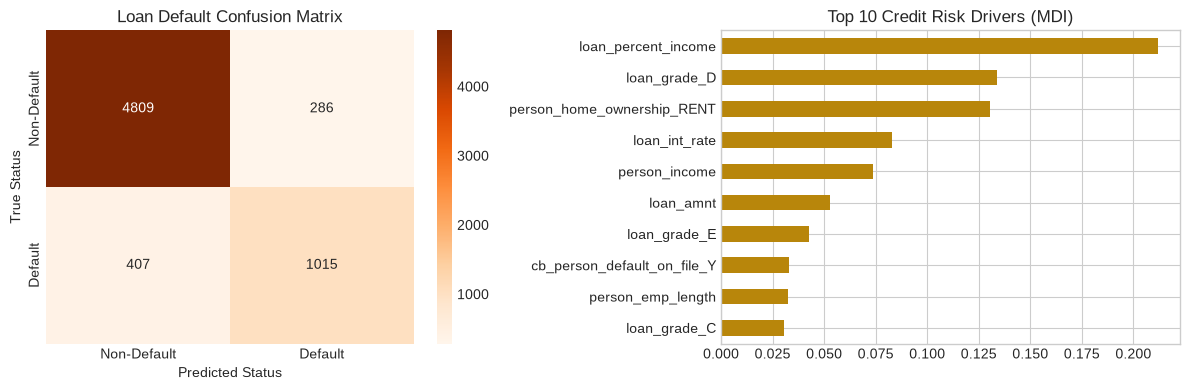

In [9]:
# STEP 11: CONFUSION MATRIX & FEATURE IMPORTANCES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Non-Default', 'Default'], yticklabels=['Non-Default', 'Default'])
axes[0].set_title('Loan Default Confusion Matrix')
axes[0].set_ylabel('True Status')
axes[0].set_xlabel('Predicted Status')

all_features = [c.split('__')[-1] for c in preprocessor.get_feature_names_out()]
importances = pd.Series(best_et.feature_importances_, index=all_features).sort_values(ascending=False).head(10)
importances.plot(kind='barh', ax=axes[1], color='darkgoldenrod')
axes[1].set_title('Top 10 Credit Risk Drivers (MDI)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time loan underwriting latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('extratrees', best_et)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/credit_risk_extratrees_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_loan = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_loan)

t0 = time.perf_counter()
pred_cls = loaded_pipe.predict(sample_loan)[0]
pred_proba = loaded_pipe.predict_proba(sample_loan)[0, 1]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME UNDERWRITING TELEMETRY:")
print(f"   Estimated Default Probability : 💳 {pred_proba * 100:.2f}% (Decision: {'Decline/Review' if pred_cls == 1 else 'Approve'})")
print(f"   Actual Recorded Outcome       : {'Default' if y_test.iloc[0] == 1 else 'Non-Default'}")
print(f"   Underwriting Latency          : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/credit_risk_extratrees_pipeline.joblib (10,704,424 bytes)



📈 REAL-TIME UNDERWRITING TELEMETRY:
   Estimated Default Probability : 💳 34.28% (Decision: Approve)
   Actual Recorded Outcome       : Non-Default
   Underwriting Latency          : 63.773 ms (SLA < 2.0ms: CHECK)
